# CSCI-4041 - Algorithms - Midterm Project

## Part 3: AVL Tree Experimentation

**3/2026**

**Created by: Dhiima Mohamed (moha2465@umn.edu)**

### Sources:
- Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to Algorithms*, 4th ed. MIT Press.
- Upton Azzam, J. (2026). *CSCI-4041 Ch13 Balanced Search Trees* [Course notebook].


## Load files

In [54]:
import random

In [55]:
%%capture
%run Ch12_BinarySearchTree.ipynb
%run Ch13_BalancedSearchTrees.ipynb
%run avl_tree.ipynb

<mark>_____________________________________________________________________________________</mark>

## Part 1: Test Case Generation

### Best Case Data




Balanced sequence: [20, 10, 30, 5, 15, 25, 35]

 The tree should be perfectly balanced


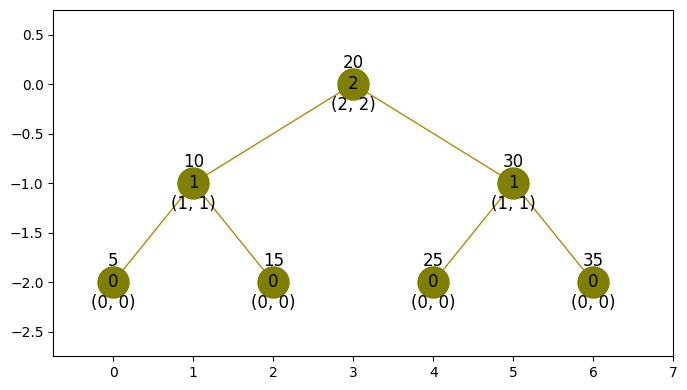

In [56]:

best_case = [20, 10, 30, 5, 15, 25, 35]
print(f"\nBalanced sequence: {best_case}")

T_best = avltree()
for k in best_case:
    T_best.insert(k)

print("\n The tree should be perfectly balanced")
PrintTree(T_best)

### Worst Case Data

Worst case (ascending): [1, 2, 3, 4, 5, 6, 7]


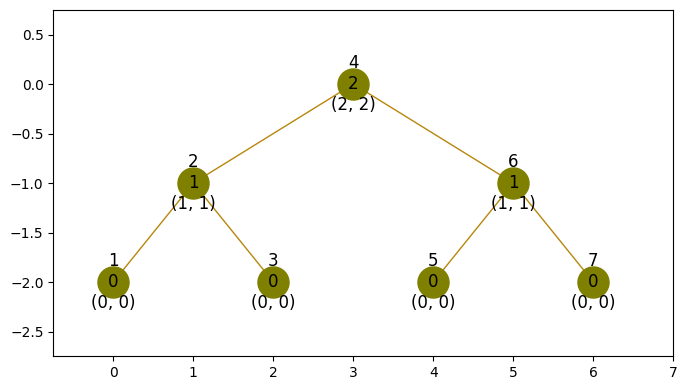

Tree height: 2


In [70]:
worst_case = [1, 2, 3, 4, 5, 6, 7]
print(f"Worst case (ascending): {worst_case}")

avl_worst = avltree()
for k in worst_case:
    avl_worst.insert(k)
PrintTree(avl_worst)
print(f"Tree height: {avl_worst.root.height}")

### Average Case Data


Average case (random): [82, 15, 4, 95, 36, 32, 29, 18, 14, 87, 70, 12, 76, 55, 5]


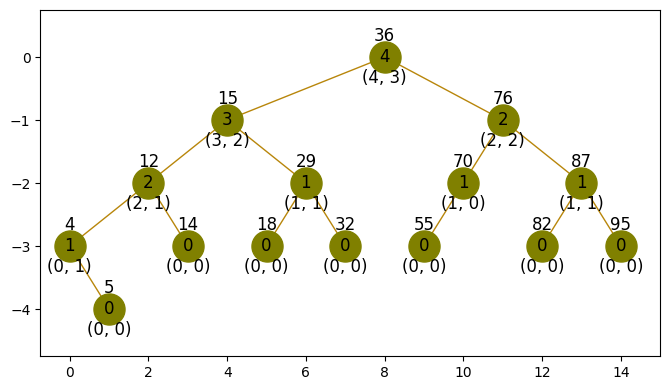

Tree height: 4


In [58]:
# Generate random keys
random.seed(42)
avg_case = random.sample(range(1, 100), 15)
print(f"Average case (random): {avg_case}")

avl_avg = avltree()
for k in avg_case:
    avl_avg.insert(k)
PrintTree(avl_avg)
print(f"Tree height: {avl_avg.root.height}")

<mark>_____________________________________________________________________________________</mark>

## Part 2: Rebalancing Cases Demonstration


### RR Case (Left Rotation)



RR Case - Inserting [10, 20, 30]


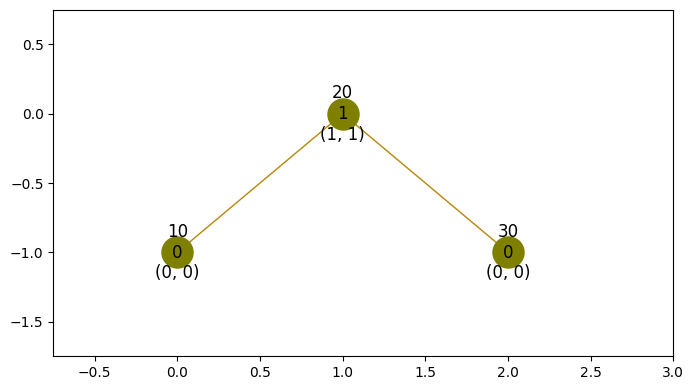

In [59]:
print("RR Case - Inserting [10, 20, 30]")
avl_rr = avltree()
avl_rr.insert(10)
avl_rr.insert(20)
avl_rr.insert(30)
PrintTree(avl_rr)

### LL Case (Right Rotation)



LL Case - Inserting [30, 20, 10]


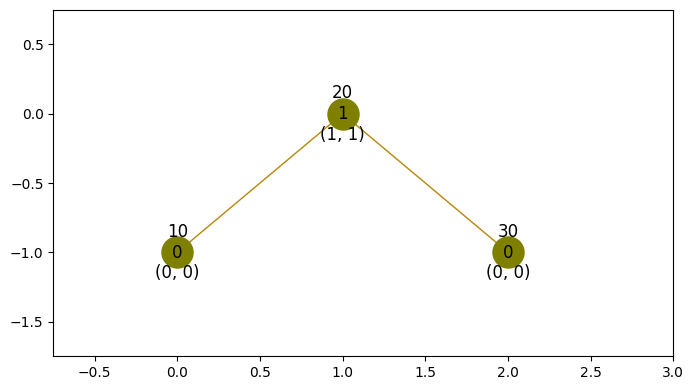

In [60]:
print("LL Case - Inserting [30, 20, 10]")
avl_ll = avltree()
avl_ll.insert(30)
avl_ll.insert(20)
avl_ll.insert(10)
PrintTree(avl_ll)

### LR Case (Left-Right Rotation)


LR Case - Inserting [30, 10, 20]


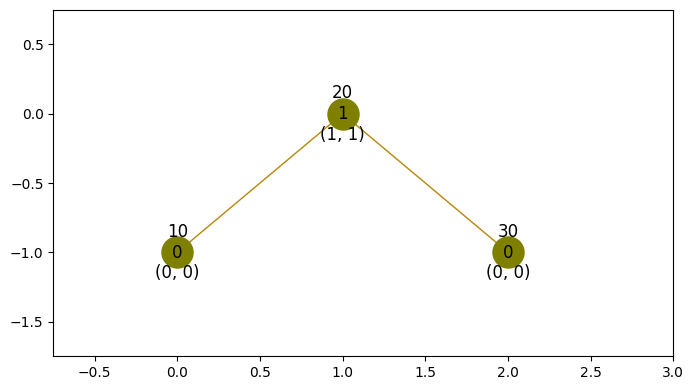

In [61]:
print("LR Case - Inserting [30, 10, 20]")
avl_lr = avltree()
avl_lr.insert(30)
avl_lr.insert(10)
avl_lr.insert(20)
PrintTree(avl_lr)

### RL Case (Right-Left Rotation)



RL Case - Inserting [10, 30, 20]


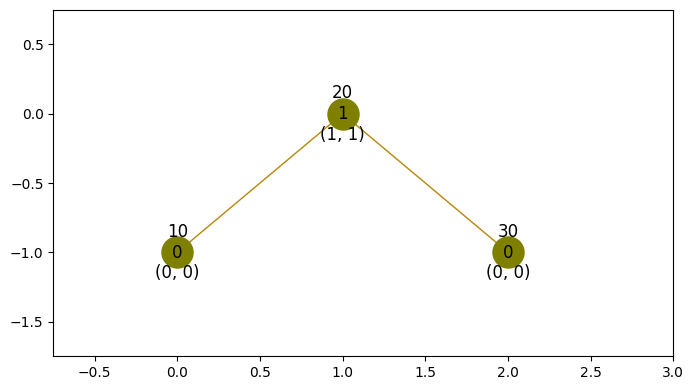

In [62]:
print("RL Case - Inserting [10, 30, 20]")
avl_rl = avltree()
avl_rl.insert(10)
avl_rl.insert(30)
avl_rl.insert(20)
PrintTree(avl_rl)

<mark>_____________________________________________________________________________________</mark>

## Part 3: Correctness Tests


In [63]:
def check_avl(tree):
    
    def get_height(node):
        if node is None:
            return 0
        return node.height
    
    def check(node):
        if node is None:
            return True
        
        # Gets the heights of children
        left_h = get_height(node.left)
        right_h = get_height(node.right)
        
        # Check balance factor
        if abs(left_h - right_h) > 1:
            print(f"Node {node.key} has balance factor {left_h - right_h}")
            return False
        
        # Recursively check children
        return check(node.left) and check(node.right)
    
    return check(tree.root)

### Test with Random Insertions

30 insertions verified


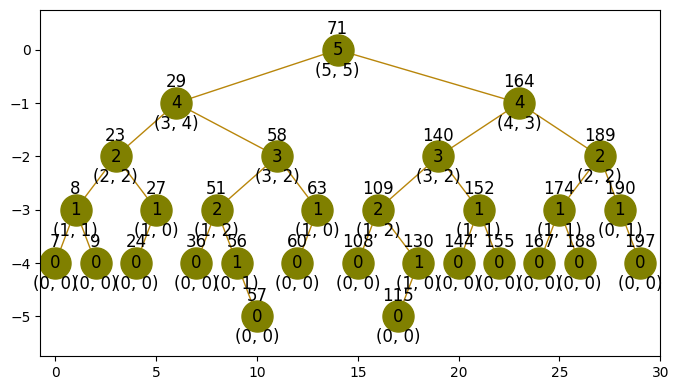

In [66]:
random.seed(42)
keys = random.sample(range(1, 200), 30)
t = avltree()

for k in keys:
    t.insert(k)
    assert check_avl(t)
print("30 insertions verified")
PrintTree(t)

### Test with Random Deletions

key = 29 was found
key = 7 was found
key = 190 was found
key = 71 was found
key = 63 was found
key = 58 was found
key = 36 was found
key = 189 was found
key = 27 was found
key = 174 was found
key = 140 was found
key = 23 was found
key = 152 was found
key = 109 was found
15 deletions verified


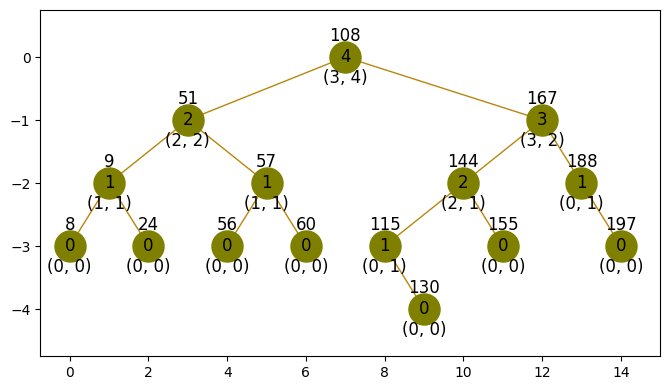

In [68]:
for k in keys[:15]:
    t.delete(k)
    assert check_avl(t)
print("15 deletions verified")
PrintTree(t)

### Verify Sorted Order Extraction

Sorted correctly: True


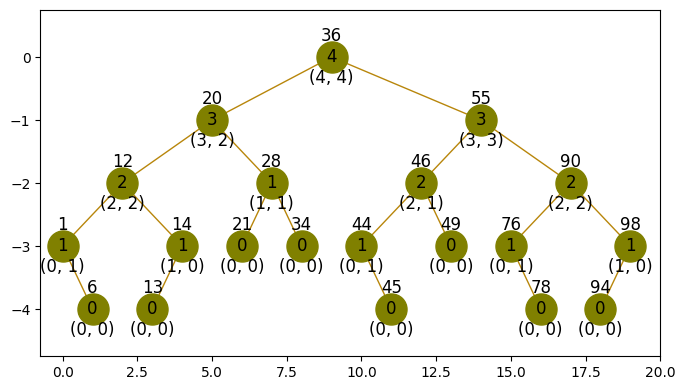

In [69]:
def inorder(n, res):
    if n:
        inorder(n.left, res)
        res.append(n.key)
        inorder(n.right, res)

t = avltree()
test = random.sample(range(1, 100), 20)
for k in test: t.insert(k)

res = []
inorder(t.root, res)
print(f"Sorted correctly: {res == sorted(test)}")
PrintTree(t)

<mark>_____________________________________________________________________________________</mark>

## Part 4: Performance Timing Tests


In [79]:
import time

# Test data
sizes = [10, 50, 100, 500, 1000]

print("INSERTION TIMING")
for size in sizes:
    keys = random.sample(range(1, size * 10), size)
    tree = avltree()
    
    start = time.time()
    for k in keys:
        tree.insert(k)
    elapsed = time.time() - start
    
    print(f"Size {size}: {elapsed:.4f} seconds")

print("\nSEARCH TIMING")
for size in sizes:
    keys = random.sample(range(1, size * 10), size)
    tree = avltree()
    for k in keys:
        tree.insert(k)
    
    start = time.time()
    for k in keys[:100]:
        tree.search(tree.root, k)
    elapsed = time.time() - start
    
    print(f"Size {size}: {elapsed:.4f} seconds")

print("\nDELETION TIMING")
for size in sizes:
    keys = random.sample(range(1, size * 10), size)
    tree = avltree()
    for k in keys:
        tree.insert(k)
    
    start = time.time()
    for k in keys[:size//2]:
        tree.delete(k)
    elapsed = time.time() - start
    
    print(f"Size {size}: {elapsed:.4f} seconds")

INSERTION TIMING
Size 10: 0.0001 seconds
Size 50: 0.0003 seconds
Size 100: 0.0010 seconds
Size 500: 0.0045 seconds
Size 1000: 0.0094 seconds

SEARCH TIMING
Size 10: 0.0000 seconds
Size 50: 0.0000 seconds
Size 100: 0.0001 seconds
Size 500: 0.0001 seconds
Size 1000: 0.0001 seconds

DELETION TIMING
key = 68 was found
key = 37 was found
key = 44 was found
key = 93 was found
key = 48 was found
Size 10: 0.0001 seconds
key = 10 was found
key = 229 was found
key = 190 was found
key = 214 was found
key = 127 was found
key = 108 was found
key = 484 was found
key = 168 was found
key = 353 was found
key = 120 was found
key = 466 was found
key = 447 was found
key = 463 was found
key = 161 was found
key = 325 was found
key = 469 was found
key = 462 was found
key = 498 was found
key = 244 was found
key = 403 was found
key = 144 was found
key = 285 was found
key = 175 was found
key = 296 was found
key = 407 was found
Size 50: 0.0004 seconds
key = 394 was found
key = 769 was found
key = 152 was found
k